# Explainable Loan Default Risk Scoring System

# Notebook 4: Model Explainability using SHAP

# Introduction

## Objective

Machine learning models often achieve high predictive performance, but understanding the reasons behind their predictions is equally important.

This notebook demonstrates Explainable Artificial Intelligence (XAI) using SHAP (SHapley Additive exPlanations). SHAP explains how each feature contributes to the predictions made by the trained Random Forest classifier.

The notebook includes:

- Loading the trained model
- Preparing the dataset
- Computing SHAP values
- Global feature importance
- Local prediction explanation

# What is Explainable AI (XAI)?

Explainable Artificial Intelligence (XAI) aims to make machine learning models transparent and understandable.

Instead of treating the model as a black box, XAI helps answer important questions such as:

- Why was this prediction made?
- Which features influenced the prediction the most?
- Can the prediction be trusted?

Explainability is especially important in finance, healthcare, and banking where model transparency is essential.

# What is SHAP?

SHAP (SHapley Additive exPlanations) is an explainability technique based on Shapley values from cooperative game theory.

It assigns an importance value to each feature by measuring its contribution to a prediction.

SHAP provides:

- Global model explanations
- Local prediction explanations
- Consistent feature importance
- Model-agnostic interpretability

# Load Required Libraries

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import shap
import joblib

# Load Dataset

In [28]:
df = pd.read_csv("../data/Loan_Default.csv")

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Data Preprocessing

In [29]:
if "LoanID" in df.columns:
    df.drop("LoanID", axis=1, inplace=True)

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


# Train-Test Split

In [30]:
X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Load Trained Random Forest Model

In [31]:
rf_model = joblib.load("../models/random_forest_model.pkl")

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


# Initialize SHAP TreeExplainer

In [32]:
explainer = shap.TreeExplainer(rf_model)

print("TreeExplainer initialized successfully!")

TreeExplainer initialized successfully!


# Generate SHAP Values

To reduce computation time, SHAP values are calculated using a representative sample of the testing dataset.

In [33]:
X_sample = X_test.sample(200, random_state=42)

print(X_sample.shape)

(200, 16)


In [34]:
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


# Global Feature Importance

The SHAP summary plot ranks features according to their contribution toward loan default prediction.

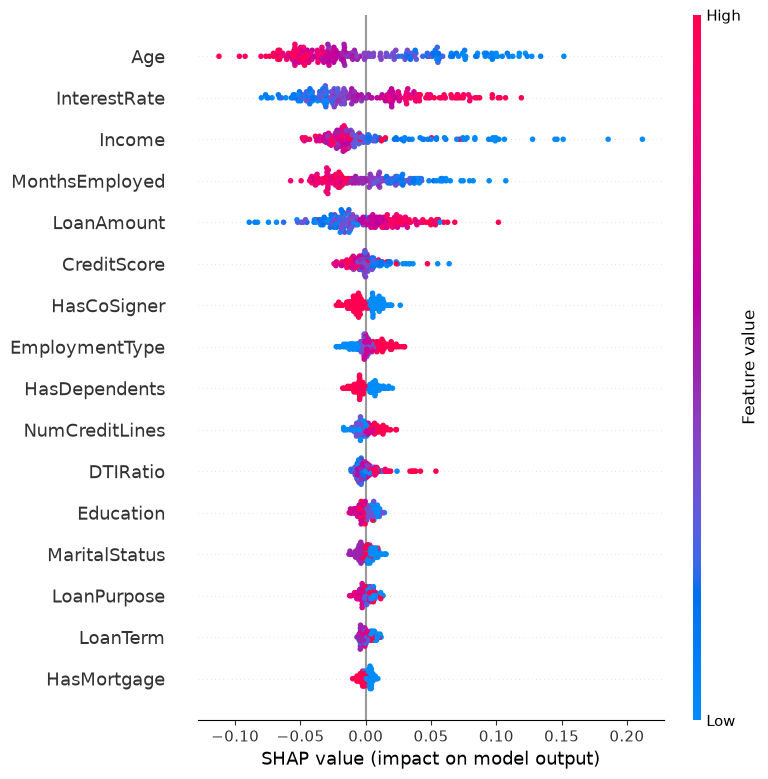

In [35]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample
)

# SHAP Feature Importance Bar Plot

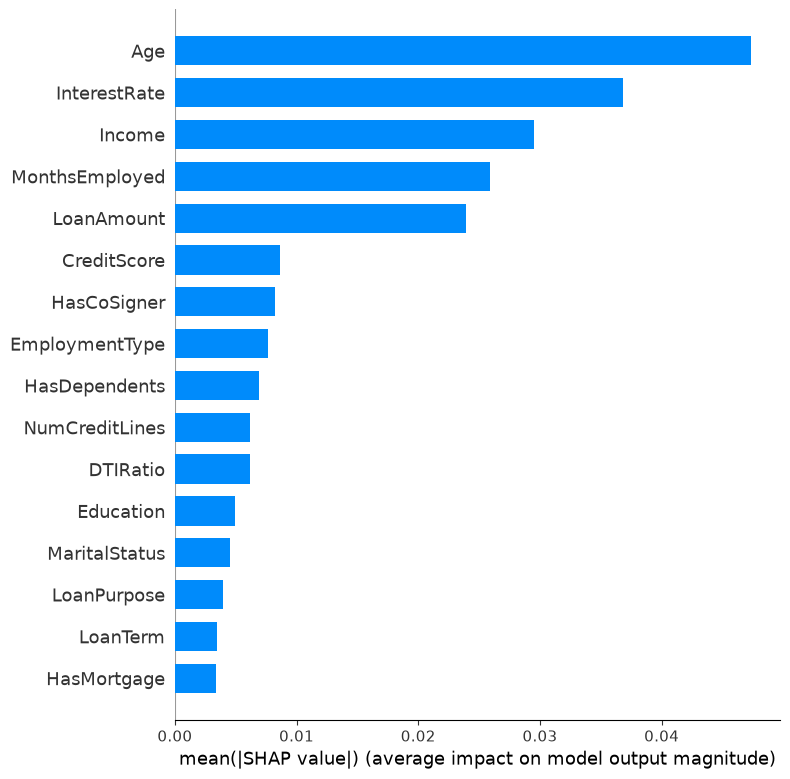

In [36]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar"
)

# Explain an Individual Prediction

The waterfall plot explains how each feature contributes to the prediction for a single loan application.

In [37]:
sample_index = 0

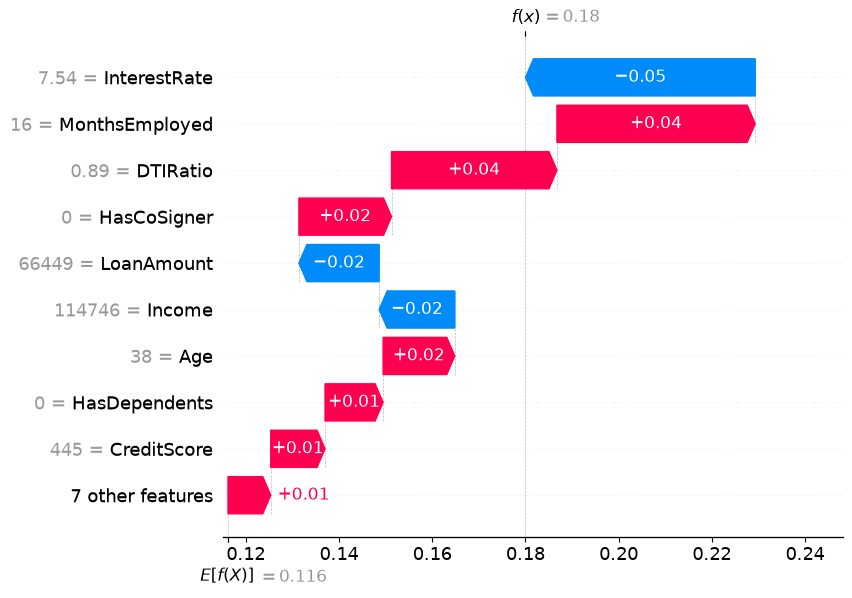

In [38]:
waterfall_explanation = shap.Explanation(
    values=shap_values[sample_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_sample.iloc[sample_index],
    feature_names=X_sample.columns
)

shap.plots.waterfall(waterfall_explanation)

# Force Plot

The force plot visualizes how each feature pushes the prediction toward or away from loan default.

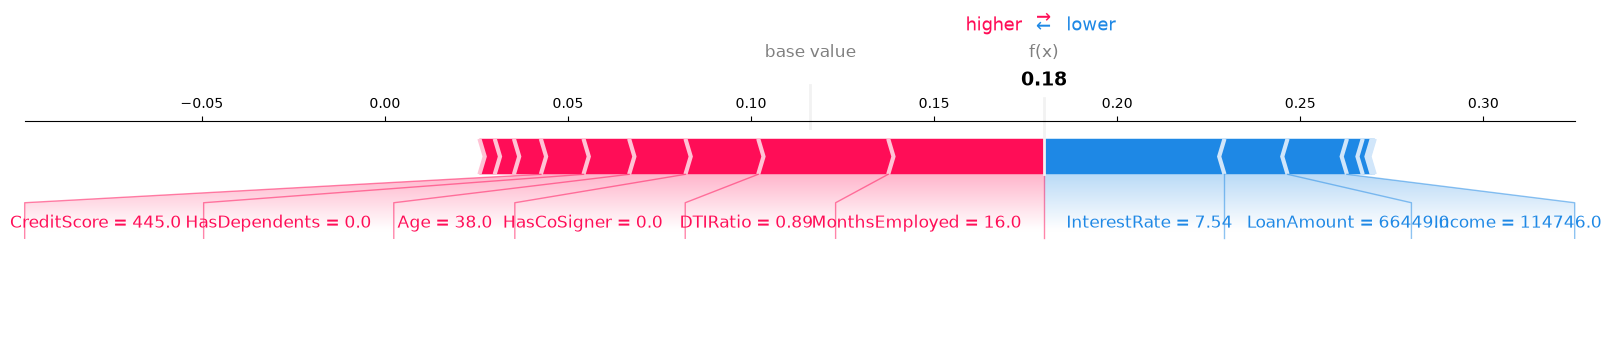

In [41]:
shap.plots.force(
    explainer.expected_value[1],
    shap_values[sample_index, :, 1],
    X_sample.iloc[sample_index],
    matplotlib=True
)

plt.show()

# Conclusion

SHAP successfully explained the predictions made by the Random Forest classifier.

The global feature importance plots identified the most influential variables affecting loan default prediction, while the waterfall and force plots provided detailed explanations for an individual applicant.

These explainability techniques improve transparency, increase trust in machine learning predictions, and make the model more suitable for real-world financial decision-making.